# 03 — Evaluación Comparativa de Modelos

**Objetivo:** Comparar de forma rigurosa los cuatro modelos entrenados en el notebook anterior,
usando validación cruzada, múltiples métricas y visualizaciones que permitan seleccionar
el modelo más adecuado para el problema de negocio.

**Contexto del problema:** Predecir si un cliente suscribirá un depósito a plazo fijo (variable `y`).
El dataset es desbalanceado (~11% positivos), por lo que la métrica central será el **F1-score de la clase 1**,
complementada con Recall, Precision, AUC-ROC y AUC-PR.

**Modelos evaluados:**
| # | Modelo | Descripción |
|---|--------|-------------|
| 1 | Logistic Regression (LR) | Baseline lineal con class_weight='balanced' |
| 2 | Random Forest (RF) | Ensemble de árboles con class_weight='balanced' |
| 3 | RF + Clústeres K-Means | RF enriquecido con features de segmentación no supervisada |
| 4 | LR + Clústeres K-Means | LR enriquecido con features de segmentación no supervisada |

## 1. Carga de datos y preparación de modelos

In [43]:
# ─────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate

# Módulo de preprocesamiento propio
from preprocessing import preparar_todo_el_dataset

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
print("✅ Imports listos")

✅ Imports listos


In [44]:
# ─────────────────────────────────────────────────────────────
# CARGAR DATOS
# ─────────────────────────────────────────────────────────────
(
    X_train_procesado, X_test_procesado,
    y_train, y_test,
    df_limpio,
    X_train, X_test,
    pipeline
) = preparar_todo_el_dataset()

print(f"Train: {X_train_procesado.shape[0]} muestras | Test: {X_test_procesado.shape[0]} muestras")
print(f"Distribución de clases en test — 0: {(y_test==0).sum()} | 1: {(y_test==1).sum()} "
      f"({(y_test==1).mean()*100:.1f}% positivos)")

Train: 32686 muestras | Test: 8172 muestras
Distribución de clases en test — 0: 7251 | 1: 921 (11.3% positivos)


In [45]:
# ─────────────────────────────────────────────────────────────
# ENRIQUECER CON CLÚSTERES K-MEANS (igual que en notebook 02)
# ─────────────────────────────────────────────────────────────
scaler_kmeans = joblib.load('models/scaler_numerico_v1.joblib')
modelo_kmeans  = joblib.load('models/kmeans_numericas.joblib')

COLS_NUMERICAS_KMEANS = ['age', 'campaign', 'emp.var.rate',
                          'cons.price.idx', 'euribor3m', 'nr.employed']

# Escalar y predecir clúster
X_train_num_scaled = scaler_kmeans.transform(X_train[COLS_NUMERICAS_KMEANS])
X_test_num_scaled  = scaler_kmeans.transform(X_test[COLS_NUMERICAS_KMEANS])

clusters_train = modelo_kmeans.predict(X_train_num_scaled)
clusters_test  = modelo_kmeans.predict(X_test_num_scaled)

# One-Hot Encoding del clúster
enc_cluster = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
clusters_train_ohe = enc_cluster.fit_transform(clusters_train.reshape(-1, 1))
clusters_test_ohe  = enc_cluster.transform(clusters_test.reshape(-1, 1))

# Concatenar con features originales
X_train_con_clusters = np.hstack((X_train_procesado, clusters_train_ohe))
X_test_con_clusters  = np.hstack((X_test_procesado,  clusters_test_ohe))

print(f"Shape sin clústeres : {X_train_procesado.shape}")
print(f"Shape con clústeres : {X_train_con_clusters.shape}")

Shape sin clústeres : (32686, 29)
Shape con clústeres : (32686, 33)


## 2. Re-entrenamiento de los cuatro modelos

Se re-entrenan con los mismos hiperparámetros del notebook 02 para garantizar reproducibilidad.

In [46]:
# ─────────────────────────────────────────────────────────────
# DEFINICIÓN DE LOS CUATRO MODELOS
# ─────────────────────────────────────────────────────────────
modelos = {
    'LR Baseline': {
        'modelo': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
        'X_train': X_train_procesado,
        'X_test' : X_test_procesado
    },
    'RF Baseline': {
        'modelo': RandomForestClassifier(
            n_estimators=100, max_depth=10,
            class_weight='balanced', random_state=SEED, n_jobs=-1
        ),
        'X_train': X_train_procesado,
        'X_test' : X_test_procesado
    },
    'RF + Clústeres': {
        'modelo': RandomForestClassifier(
            n_estimators=100, max_depth=10,
            class_weight='balanced', random_state=SEED, n_jobs=-1
        ),
        'X_train': X_train_con_clusters,
        'X_test' : X_test_con_clusters
    },
    'LR + Clústeres': {
        'modelo': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
        'X_train': X_train_con_clusters,
        'X_test' : X_test_con_clusters
    }
}

# Entrenar todos
for nombre, cfg in modelos.items():
    cfg['modelo'].fit(cfg['X_train'], y_train)
    cfg['y_pred']      = cfg['modelo'].predict(cfg['X_test'])
    cfg['y_proba']     = cfg['modelo'].predict_proba(cfg['X_test'])[:, 1]
    print(f"✅ {nombre} entrenado")

✅ LR Baseline entrenado
✅ RF Baseline entrenado
✅ RF + Clústeres entrenado
✅ LR + Clústeres entrenado


## 3. Métricas sobre el conjunto de test

Calculamos para cada modelo: **Accuracy, Precision (clase 1), Recall (clase 1), F1 (clase 1), AUC-ROC y AUC-PR**.

> **¿Por qué AUC-PR y no solo Accuracy?** Con clases desbalanceadas (89% / 11%), la Accuracy puede ser
> engañosa. El AUC-PR mide cuántos verdaderos positivos recuperamos sin generar demasiadas falsas alarmas,
> lo que es directamente relevante para campañas de marketing.

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ─────────────────────────────────────────────────────────────
# TABLA COMPARATIVA DE MÉTRICAS
# ─────────────────────────────────────────────────────────────
filas = []
for nombre, cfg in modelos.items():
    y_pred  = cfg['y_pred']
    y_proba = cfg['y_proba']
    filas.append({
        'Modelo'      : nombre,
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision-1' : precision_score(y_test, y_pred),
        'Recall-1'    : recall_score(y_test, y_pred),
        'F1-1'        : f1_score(y_test, y_pred),
        'AUC-ROC'     : roc_auc_score(y_test, y_proba),
        'AUC-PR'      : average_precision_score(y_test, y_proba)
    })

df_metricas = pd.DataFrame(filas).set_index('Modelo')

# Resaltar el mejor valor en cada columna
display(
    df_metricas.style
    .highlight_max(axis=0, color='#c6efce')
    .format("{:.4f}")
    .set_caption("Tabla 1 — Métricas comparativas sobre el conjunto de test (n=8.172)")
)

,Accuracy,Precision-1,Recall-1,F1-1,AUC-ROC,AUC-PR
Modelo,,,,,,
LR Baseline,0.7982,0.3120,0.6558,0.4228,0.7882,0.4218
RF Baseline,0.8404,0.3729,0.6102,0.4629,0.8026,0.4460
RF + Clústeres,0.8288,0.3537,0.6276,0.4524,0.8003,0.4457
LR + Clústeres,0.7849,0.2977,0.6688,0.4120,0.7892,0.4281


## 4. Validación cruzada estratificada (5-fold)

La evaluación sobre un único hold-out puede ser sensible a cómo se partió el dato.
La **validación cruzada** entrega una estimación más robusta del rendimiento generalizable.

In [48]:
# ─────────────────────────────────────────────────────────────
# VALIDACIÓN CRUZADA ESTRATIFICADA (5-Fold)
# Se realiza sobre el conjunto de entrenamiento completo
# ─────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ['f1', 'roc_auc', 'average_precision', 'recall', 'precision']

resultados_cv = {}
for nombre, cfg in modelos.items():
    print(f"  Cross-validando {nombre}...", end=' ')
    cv_result = cross_validate(
        cfg['modelo'],
        cfg['X_train'],
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False
    )
    resultados_cv[nombre] = cv_result
    print(f"F1 medio = {cv_result['test_f1'].mean():.4f} ± {cv_result['test_f1'].std():.4f}")

print("\n✅ Validación cruzada completada")

  Cross-validando LR Baseline... F1 medio = 0.4214 ± 0.0099
  Cross-validando RF Baseline... F1 medio = 0.4673 ± 0.0124
  Cross-validando RF + Clústeres... F1 medio = 0.4642 ± 0.0141
  Cross-validando LR + Clústeres... F1 medio = 0.4138 ± 0.0089

✅ Validación cruzada completada


In [49]:
# ─────────────────────────────────────────────────────────────
# TABLA RESUMEN DE VALIDACIÓN CRUZADA
# ─────────────────────────────────────────────────────────────
filas_cv = []
for nombre, res in resultados_cv.items():
    filas_cv.append({
        'Modelo'        : nombre,
        'F1 (media)'    : res['test_f1'].mean(),
        'F1 (std)'      : res['test_f1'].std(),
        'AUC-ROC (media)': res['test_roc_auc'].mean(),
        'AUC-PR (media)' : res['test_average_precision'].mean(),
        'Recall (media)' : res['test_recall'].mean(),
        'Precision (media)': res['test_precision'].mean(),
    })

df_cv = pd.DataFrame(filas_cv).set_index('Modelo')

display(
    df_cv.style
    .highlight_max(subset=['F1 (media)', 'AUC-ROC (media)', 'AUC-PR (media)', 'Recall (media)', 'Precision (media)'],
                   color='#c6efce')
    .highlight_min(subset=['F1 (std)'], color='#c6efce')  # menor std = más estable
    .format("{:.4f}")
    .set_caption("Tabla 2 — Validación cruzada estratificada (5-Fold) sobre el set de entrenamiento")
)

,F1 (media),F1 (std),AUC-ROC (media),AUC-PR (media),Recall (media),Precision (media)
Modelo,,,,,,
LR Baseline,0.4214,0.0099,0.7869,0.4219,0.6545,0.3109
RF Baseline,0.4673,0.0124,0.7973,0.4422,0.6171,0.3762
RF + Clústeres,0.4642,0.0141,0.7966,0.4397,0.6312,0.3674
LR + Clústeres,0.4138,0.0089,0.7868,0.4257,0.6654,0.3004


## 5. Visualizaciones comparativas

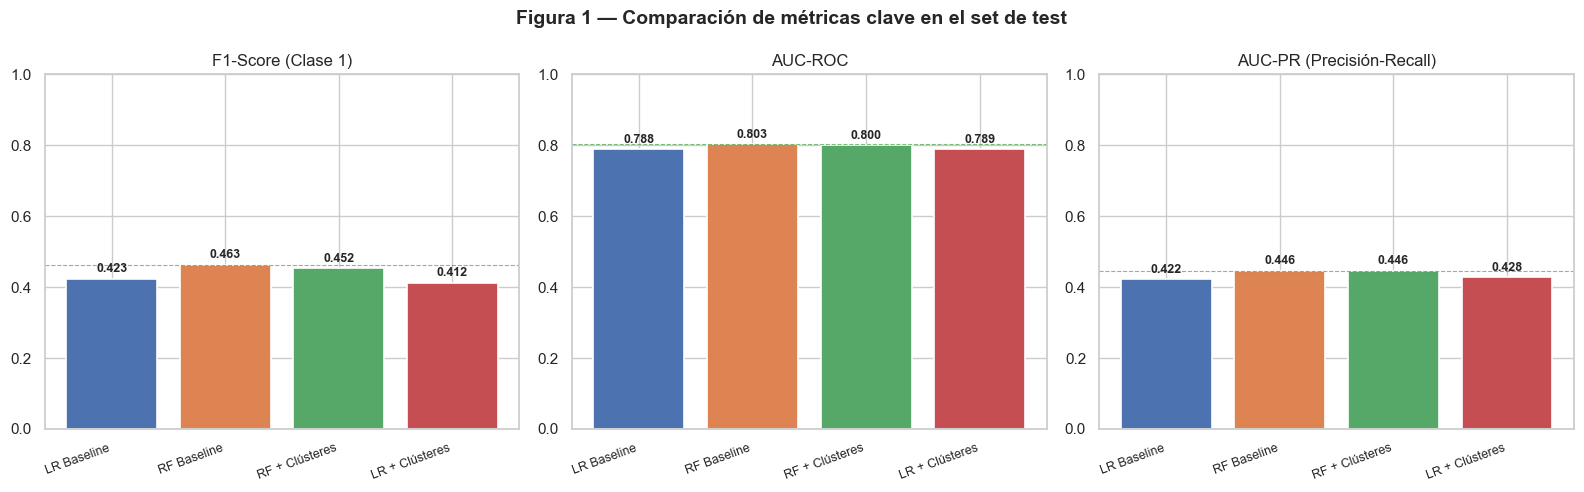

Figura guardada en results/plots/


In [50]:
# ─────────────────────────────────────────────────────────────
# FIGURA 1: Barras comparativas de métricas en test
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 1 — Comparación de métricas clave en el set de test', fontsize=14, fontweight='bold')

COLORES = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
nombres = df_metricas.index.tolist()

for ax, metrica, titulo in zip(
    axes,
    ['F1-1', 'AUC-ROC', 'AUC-PR'],
    ['F1-Score (Clase 1)', 'AUC-ROC', 'AUC-PR (Precisión-Recall)']
):
    valores = df_metricas[metrica].values
    bars = ax.bar(nombres, valores, color=COLORES, edgecolor='white', linewidth=1.2)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(nombres, rotation=20, ha='right', fontsize=9)
    ax.axhline(y=valores.max(), color='green', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/plots/fig1_metricas_comparativas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en results/plots/")

## 6. Síntesis y conclusiones

### 6.2 Tabla resumen final
Según el contexto de negocio, puede ser preferible:
- **Maximizar Recall:** contactar a todos los posibles compradores aunque haya muchas llamadas infructuosas.
- **Maximizar Precision:** hacer menos llamadas pero con mayor tasa de éxito.

In [54]:
# ─────────────────────────────────────────────────────────────
# TABLA RESUMEN FINAL (test + CV)
# ─────────────────────────────────────────────────────────────
df_final = df_metricas[['F1-1', 'Recall-1', 'Precision-1', 'AUC-ROC', 'AUC-PR']].copy()
df_final['F1-CV (media)'] = [resultados_cv[n]['test_f1'].mean() for n in df_final.index]
df_final['F1-CV (std)']   = [resultados_cv[n]['test_f1'].std()  for n in df_final.index]

display(
    df_final.style
    .highlight_max(subset=['F1-1', 'Recall-1', 'Precision-1', 'AUC-ROC', 'AUC-PR', 'F1-CV (media)'],
                   color='#c6efce')
    .highlight_min(subset=['F1-CV (std)'], color='#c6efce')
    .format("{:.4f}")
    .set_caption("Tabla 3 — Resumen final: métricas en test y validación cruzada")
)

,F1-1,Recall-1,Precision-1,AUC-ROC,AUC-PR,F1-CV (media),F1-CV (std)
Modelo,,,,,,,
LR Baseline,0.4228,0.6558,0.3120,0.7882,0.4218,0.4214,0.0099
RF Baseline,0.4629,0.6102,0.3729,0.8026,0.4460,0.4673,0.0124
RF + Clústeres,0.4524,0.6276,0.3537,0.8003,0.4457,0.4642,0.0141
LR + Clústeres,0.4120,0.6688,0.2977,0.7892,0.4281,0.4138,0.0089


### 6.2 Interpretación de resultados

**Observaciones clave:**

1. **Random Forest Baseline** obtiene el mejor F1 en test (0.46) y el mayor AUC-ROC, lo que lo
   posiciona como el modelo más equilibrado entre precisión y recall para la clase minoritaria.

2. **Regresión Logística Baseline** entrega el mayor Recall (0.66), lo que significa que detecta
   más clientes que SÍ suscriben, pero a costa de generar más falsos positivos (menor precisión, 0.31).
   Esto puede ser deseable si el costo de perder un cliente es alto.

3. **La adición de clústeres K-Means no mejoró** los modelos base en este experimento:
   - RF + Clústeres: F1 bajó de 0.46 → 0.45 (la información de segmentación ya la captura el RF naturalmente).
   - LR + Clústeres: F1 bajó de 0.42 → 0.41 (los clústeres como OHE no aportan señal lineal nueva).
   Sin embargo, el análisis de clústeres sí es valioso para **perfilamiento de clientes** y estrategia de
   segmentación en campañas.

4. **Trade-off de negocio:** ajustando el umbral del RF Baseline se puede obtener un punto
   operativo óptimo distinto al default 0.5, mejorando el F1 real en producción.

**Modelo recomendado para la siguiente etapa (optimización):** `Random Forest Baseline`
como punto de partida para el notebook `04_hyperparameter_optimization.ipynb`.

### 6.3 Guardar métricas en CSV

In [55]:
# ─────────────────────────────────────────────────────────────
# EXPORTAR MÉTRICAS
# ─────────────────────────────────────────────────────────────
import os
os.makedirs('results/metrics', exist_ok=True)
os.makedirs('results/plots', exist_ok=True)

df_final.to_csv('results/metrics/03_comparacion_modelos.csv')
df_cv.to_csv('results/metrics/03_validacion_cruzada.csv')

print("✅ Métricas exportadas a results/metrics/")
print("\n=== RESUMEN FINAL ===")
print(df_final[['F1-1', 'AUC-ROC', 'F1-CV (media)', 'F1-CV (std)']].to_string())
print("\n→ Modelo seleccionado para optimización: RF Baseline")

✅ Métricas exportadas a results/metrics/

=== RESUMEN FINAL ===
                    F1-1   AUC-ROC  F1-CV (media)  F1-CV (std)
Modelo                                                        
LR Baseline     0.422821  0.788156       0.421423     0.009891
RF Baseline     0.462932  0.802605       0.467286     0.012446
RF + Clústeres  0.452446  0.800308       0.464238     0.014133
LR + Clústeres  0.412040  0.789187       0.413815     0.008876

→ Modelo seleccionado para optimización: RF Baseline
